# Data Vortex: Social Engine

## Round 1 — Phase 1: Dataset Recovery and Restoration

### Objective

The objective of this project is to recover, clean, and analyze the corrupted Social Engine datasets.

The project includes handling missing values, identifying anomalies, standardizing inconsistent data, performing exploratory data analysis, and generating meaningful insights.

### Team

* Team Name:
* Members: Shubhradeep Banerjee

### Datasets

1. Social Engine Users
2. Social Engine Posts


In [5]:
from google.colab import files

uploaded = files.upload()

Saving Social_Engine_Posts_Corrupted.csv to Social_Engine_Posts_Corrupted (1).csv
Saving Social_Engine_Users.csv to Social_Engine_Users (1).csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
posts = pd.read_csv("Social_Engine_Posts_Corrupted.csv")
users = pd.read_csv("Social_Engine_Users.csv")

print("Posts dataset loaded")
print("Users dataset loaded")

Posts dataset loaded
Users dataset loaded


In [7]:
print("POSTS DATASET")
print("Shape:", posts.shape)
print("Columns:", posts.columns.tolist())
print()

print("USERS DATASET")
print("Shape:", users.shape)
print("Columns:", users.columns.tolist())

POSTS DATASET
Shape: (12360, 8)
Columns: ['post_id', 'user_id', 'platform', 'text_content', 'timestamp', 'likes', 'shares', 'comments']

USERS DATASET
Shape: (1500, 5)
Columns: ['user_id', 'location', 'language', 'account_created', 'follower_count']


In [8]:
print("Posts information:")
posts.info()

print("\nMissing values in Posts:")
print(posts.isnull().sum())

print("\nDuplicate rows in Posts:")
print(posts.duplicated().sum())

print("\nUsers information:")
users.info()

print("\nMissing values in Users:")
print(users.isnull().sum())

print("\nDuplicate rows in Users:")
print(users.duplicated().sum())

Posts information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12360 entries, 0 to 12359
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   post_id       12360 non-null  object 
 1   user_id       12360 non-null  object 
 2   platform      10514 non-null  object 
 3   text_content  10614 non-null  object 
 4   timestamp     12360 non-null  object 
 5   likes         10502 non-null  float64
 6   shares        12360 non-null  int64  
 7   comments      12360 non-null  int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 772.6+ KB

Missing values in Posts:
post_id            0
user_id            0
platform        1846
text_content    1746
timestamp          0
likes           1858
shares             0
comments           0
dtype: int64

Duplicate rows in Posts:
360

Users information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column     

In [9]:
posts_clean = posts.copy()
users_clean = users.copy()

In [10]:
print("Missing values before cleaning:")
print(posts_clean.isnull().sum())

Missing values before cleaning:
post_id            0
user_id            0
platform        1846
text_content    1746
timestamp          0
likes           1858
shares             0
comments           0
dtype: int64


In [11]:
posts_clean["platform"] = posts_clean["platform"].fillna("Unknown Platform")

posts_clean["text_content"] = posts_clean["text_content"].fillna(
    "No text content available"
)

posts_clean["likes"] = posts_clean["likes"].fillna(0)

In [12]:
posts_clean["platform"] = posts_clean["platform"].str.strip()
posts_clean["text_content"] = posts_clean["text_content"].str.strip()

users_clean["location"] = users_clean["location"].str.strip()
users_clean["language"] = users_clean["language"].str.strip()

In [13]:
print("Duplicate rows before cleaning:", posts_clean.duplicated().sum())

posts_clean = posts_clean.drop_duplicates()

print("Duplicate rows after cleaning:", posts_clean.duplicated().sum())

Duplicate rows before cleaning: 360
Duplicate rows after cleaning: 0


In [14]:
print("Duplicate post IDs:")
print(posts_clean["post_id"].duplicated().sum())
posts_clean = posts_clean.drop_duplicates(
    subset=["post_id"],
    keep="first"
)

Duplicate post IDs:
0


In [15]:
negative_likes = (posts_clean["likes"] < 0).sum()

print("Negative likes before cleaning:", negative_likes)

posts_clean.loc[posts_clean["likes"] < 0, "likes"] = 0

print(
    "Negative likes after cleaning:",
    (posts_clean["likes"] < 0).sum()
)

Negative likes before cleaning: 509
Negative likes after cleaning: 0


In [16]:
print("Negative shares:", (posts_clean["shares"] < 0).sum())
print("Negative comments:", (posts_clean["comments"] < 0).sum())

Negative shares: 0
Negative comments: 0


In [17]:
def convert_timestamp(value):
    value = str(value)

    # Unix timestamp
    if value.isdigit():
        return pd.to_datetime(
            int(value),
            unit="s",
            errors="coerce"
        )

    # DD-MM-YYYY format
    if len(value) == 10 and value[2] == "-" and value[5] == "-":
        return pd.to_datetime(
            value,
            format="%d-%m-%Y",
            errors="coerce"
        )

    # ISO format
    return pd.to_datetime(value, errors="coerce")


posts_clean["timestamp"] = posts_clean["timestamp"].apply(
    convert_timestamp
)

print(posts_clean["timestamp"].head())
print("Invalid timestamps:", posts_clean["timestamp"].isnull().sum())

0   2024-09-25 00:00:00
1   2024-08-01 16:14:00
2   2025-04-13 20:12:18
3   2024-09-10 00:00:00
4   2024-05-31 00:00:00
Name: timestamp, dtype: datetime64[ns]
Invalid timestamps: 0


In [18]:
posts_clean["timestamp"] = posts_clean["timestamp"].dt.strftime(
    "%Y-%m-%d %H:%M:%S"
)

posts_clean["timestamp"] = pd.to_datetime(
    posts_clean["timestamp"],
    errors="coerce"
)

print(posts_clean["timestamp"].head())

0   2024-09-25 00:00:00
1   2024-08-01 16:14:00
2   2025-04-13 20:12:18
3   2024-09-10 00:00:00
4   2024-05-31 00:00:00
Name: timestamp, dtype: datetime64[ns]


In [19]:
print("Posts numerical summary:")
display(posts_clean.describe())

print("Users numerical summary:")
display(users_clean.describe())

Posts numerical summary:


,timestamp,likes,shares,comments
count,12000,12000.000000,12000.000000,12000.00000
mean,2024-10-30 05:40:29.458749952,2010.804083,1007.167167,504.34575
min,2024-05-01 00:00:00,0.000000,0.000000,0.00000
25%,2024-07-31 14:06:23,360.750000,510.000000,253.00000
50%,2024-10-31 00:00:00,1887.000000,1018.000000,503.00000
75%,2025-01-28 11:11:21,3450.000000,1501.000000,755.00000
max,2025-04-30 21:57:10,5000.000000,2000.000000,1000.00000
std,NaN,1624.460886,575.072282,288.68416


Users numerical summary:


,follower_count
count,1500.000000
mean,24964.019333
std,14185.477457
min,109.000000
25%,12771.750000
50%,24741.500000
75%,37097.250000
max,49944.000000


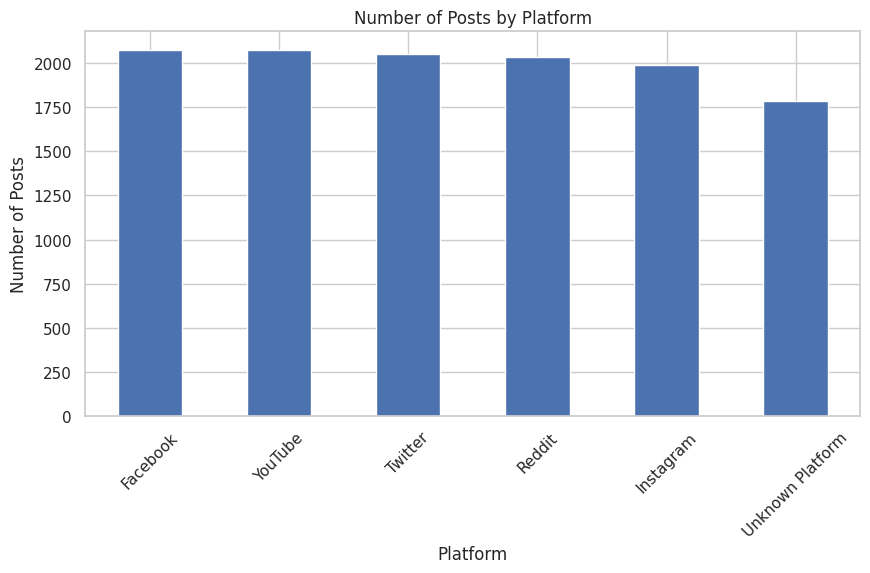

In [20]:
platform_counts = posts_clean["platform"].value_counts()

plt.figure(figsize=(10, 5))
platform_counts.plot(kind="bar")

plt.title("Number of Posts by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.show()

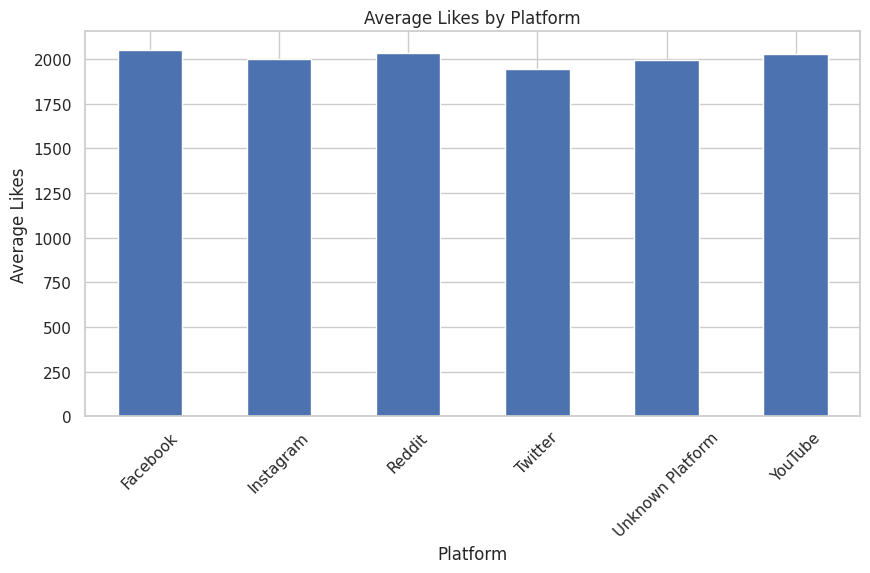

In [21]:
average_likes = posts_clean.groupby("platform")["likes"].mean()

plt.figure(figsize=(10, 5))
average_likes.plot(kind="bar")

plt.title("Average Likes by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Likes")
plt.xticks(rotation=45)
plt.show()

,likes,shares,comments
platform,,,
Facebook,2052.668274,984.173578,506.936837
Instagram,2002.884867,1040.836099,499.804424
Reddit,2037.029542,1002.228951,511.175283
Twitter,1943.320644,1005.391410,506.126403
Unknown Platform,1996.896300,998.605381,496.536435
YouTube,2029.494935,1011.828751,504.380125


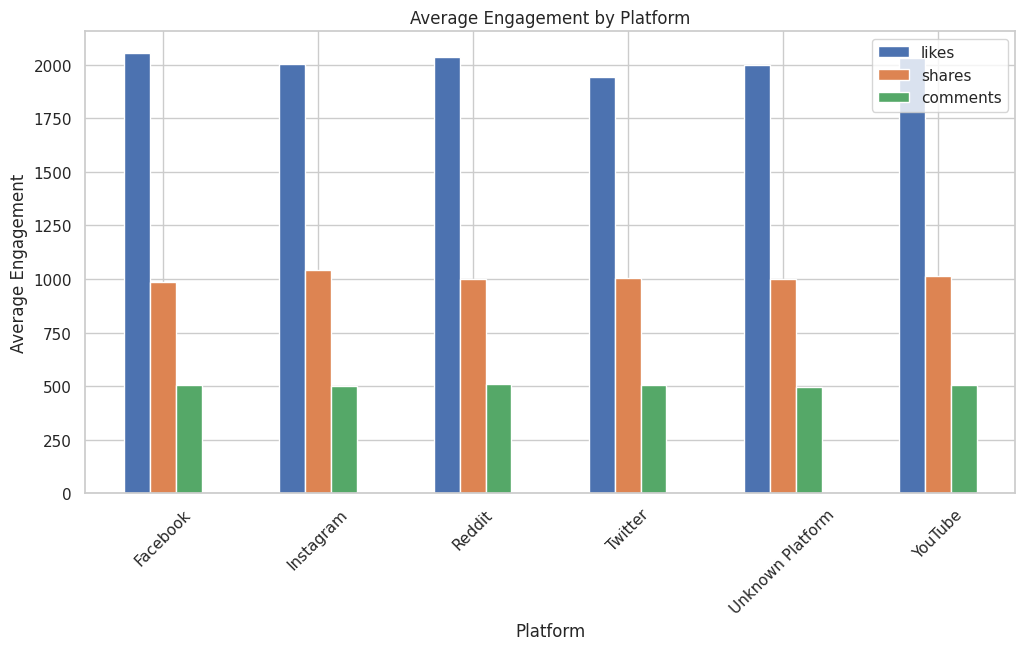

In [22]:
platform_engagement = posts_clean.groupby("platform")[
    ["likes", "shares", "comments"]
].mean()

display(platform_engagement)

platform_engagement.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Engagement by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Engagement")
plt.xticks(rotation=45)
plt.show()

,count
user_id,
user_zqv2vrf5,22
user_nfo3ih5u,19
user_8wk0j5ae,18
user_n0ok02rt,18
user_q3vs0uj7,18
user_0irp4abu,17
user_xetn4exw,16
user_ujllj1n7,16
user_i1e1kek5,16


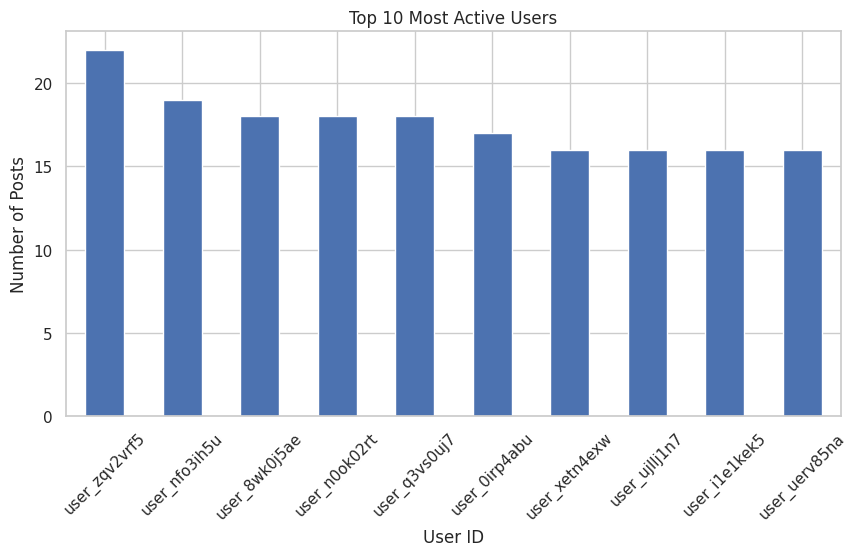

In [23]:
most_active_users = posts_clean["user_id"].value_counts().head(10)

display(most_active_users)

plt.figure(figsize=(10, 5))
most_active_users.plot(kind="bar")

plt.title("Top 10 Most Active Users")
plt.xlabel("User ID")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.show()

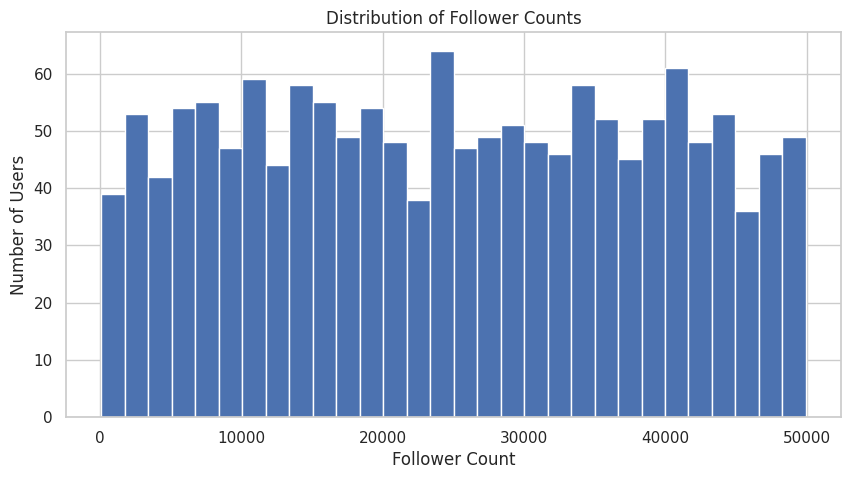

In [24]:
plt.figure(figsize=(10, 5))

plt.hist(
    users_clean["follower_count"],
    bins=30
)

plt.title("Distribution of Follower Counts")
plt.xlabel("Follower Count")
plt.ylabel("Number of Users")
plt.show()

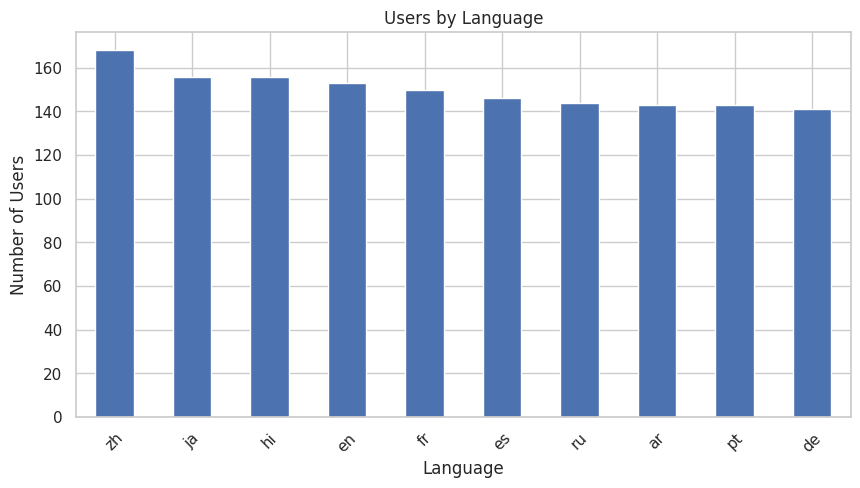

In [25]:
language_counts = users_clean["language"].value_counts()

plt.figure(figsize=(10, 5))
language_counts.plot(kind="bar")

plt.title("Users by Language")
plt.xlabel("Language")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.show()

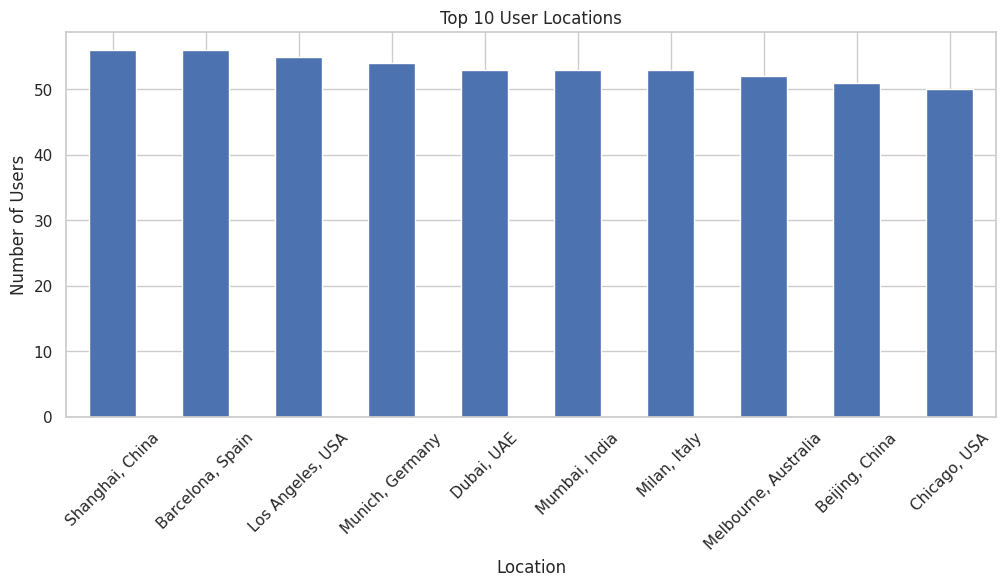

In [26]:
location_counts = users_clean["location"].value_counts().head(10)

plt.figure(figsize=(12, 5))
location_counts.plot(kind="bar")

plt.title("Top 10 User Locations")
plt.xlabel("Location")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.show()

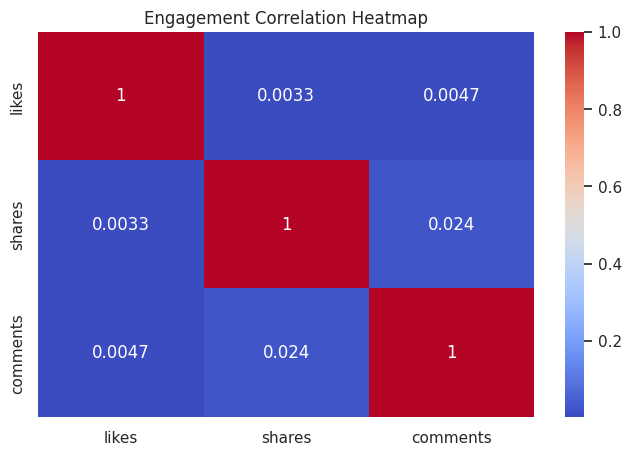

In [27]:
numeric_columns = posts_clean[
    ["likes", "shares", "comments"]
]

plt.figure(figsize=(8, 5))

sns.heatmap(
    numeric_columns.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Engagement Correlation Heatmap")
plt.show()

In [28]:
posts_clean["engagement_score"] = (
    posts_clean["likes"]
    + posts_clean["shares"]
    + posts_clean["comments"]
)

top_posts = posts_clean.sort_values(
    by="engagement_score",
    ascending=False
).head(10)

display(
    top_posts[
        [
            "post_id",
            "platform",
            "likes",
            "shares",
            "comments",
            "engagement_score"
        ]
    ]
)

,post_id,platform,likes,shares,comments,engagement_score
12227,ycjj5zzt7mvx,Instagram,4983.0,1919,991,7893.0
3675,wo7py9aljg3t,Reddit,4864.0,1981,948,7793.0
10583,gmoeib832zbs,Facebook,4902.0,1880,982,7764.0
3350,5kvuyvf38nqx,YouTube,4923.0,1971,861,7755.0
8889,pvfl3d8hj7jd,Instagram,4989.0,1840,909,7738.0
8578,tdgjjylpua20,Unknown Platform,4979.0,1932,812,7723.0
5201,tne7s3o4l4wd,Instagram,4931.0,1903,878,7712.0
6738,a1kiwl618kzy,Facebook,4811.0,1952,920,7683.0
8934,fp89q1ickn9w,Twitter,4740.0,1933,955,7628.0
6646,5n161ir5hhhr,YouTube,4751.0,1981,878,7610.0


In [29]:
merged_data = posts_clean.merge(
    users_clean,
    on="user_id",
    how="left"
)

display(merged_data.head())
print("Merged shape:", merged_data.shape)

,post_id,user_id,platform,text_content,timestamp,likes,shares,comments,engagement_score,location,language,account_created,follower_count
0,to64mgey2v3y,user_vfxs1pry,Reddit,Bummed out with my new Air Max from Nike! Abso...,2024-09-25 00:00:00,4488.0,1456,673,6617.0,"Melbourne, Australia",fr,2023-10-31,19932
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,My one month review of Pepsi Crystal Pepsi: Hi...,2024-08-01 16:14:00,789.0,1484,39,2312.0,"Vancouver, Canada",ru,2023-07-04,48345
2,dvvhg8eel45x,user_nfo3ih5u,Unknown Platform,Just unboxed my new Highlander from Toyota. Ex...,2025-04-13 20:12:18,0.0,1410,839,2249.0,"Barcelona, Spain",ar,2023-10-29,40429
3,hgb9cxke4t7b,user_27aje6ur,Facebook,Comparing Pepsi Crystal Pepsi to the competiti...,2024-09-10 00:00:00,167.0,584,833,1584.0,"Berlin, Germany",hi,2023-08-08,15671
4,zwerpw3wk320,user_9px5q0by,Reddit,My one week review of Coca-Cola Diet Coke: Bes...,2024-05-31 00:00:00,4749.0,152,630,5531.0,"Lyon, France",zh,2023-12-23,46167


Merged shape: (12000, 13)


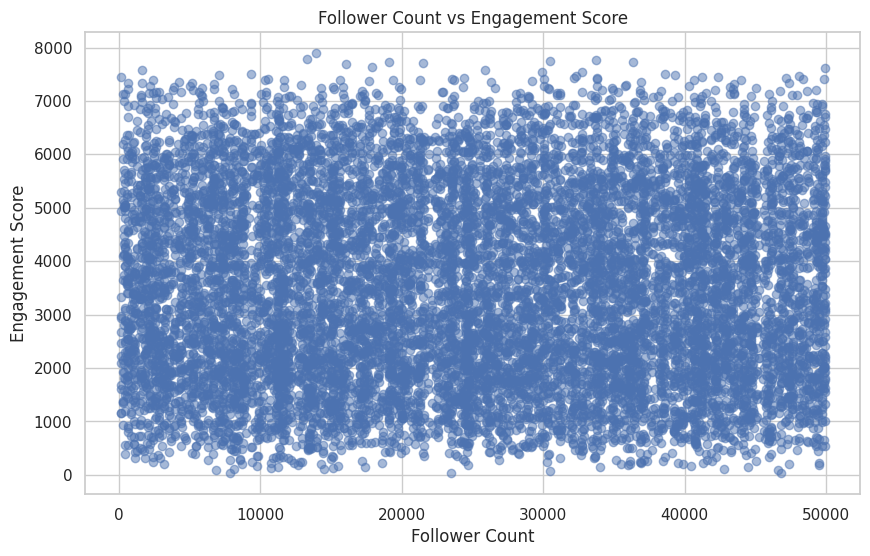

In [30]:
plt.figure(figsize=(10, 6))

plt.scatter(
    merged_data["follower_count"],
    merged_data["engagement_score"],
    alpha=0.5
)

plt.title("Follower Count vs Engagement Score")
plt.xlabel("Follower Count")
plt.ylabel("Engagement Score")
plt.show()

In [31]:
posts_clean.to_csv(
    "Social_Engine_Posts_Cleaned.csv",
    index=False
)

users_clean.to_csv(
    "Social_Engine_Users_Cleaned.csv",
    index=False
)

merged_data.to_csv(
    "Social_Engine_Merged_Analysis.csv",
    index=False
)

print("Cleaned datasets exported successfully.")

Cleaned datasets exported successfully.


In [32]:
from google.colab import files

files.download("Social_Engine_Posts_Cleaned.csv")
files.download("Social_Engine_Users_Cleaned.csv")
files.download("Social_Engine_Merged_Analysis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>